# 03. 센서·영상 데이터 문제 정의 실습

## 학습 목표
1. **영상(Vision)** 과 **센서(Sensor)** 데이터의 역할 차이를 이해한다.
2. AOI 라인에서 수집 가능한 **멀티모달 데이터** 시나리오를 설계한다.
3. 데이터 유형별 **ML 문제 정의** 방법을 실습한다.
4. 영상 어노테이션 품질 검증 및 **문제 정의 의사결정**을 수행한다.

---

## 1. 스마트 팩토리 데이터 계층

| 계층 | 데이터 유형 | 예시 | 본 프로젝트 |
|------|------------|------|------------|
| L1 설비 | 시계열 센서 | 온도, 진동, 조도 | 시뮬레이션 |
| L2 공정 | 영상 | AOI RGB 이미지 | **실제 데이터** |
| L3 품질 | 라벨 | YOLO bbox | **실제 데이터** |
| L4 MES | 로그 | Lot ID, 공정 파라미터 | 메타데이터로 확장 |

In [1]:
from pathlib import Path
import re
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path("..").resolve()
DATA_ROOT = PROJECT_ROOT / "data" / "pcb-defect-dataset" / "pcb-defect-dataset"

with open(PROJECT_ROOT / "config" / "dataset.yaml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)
CLASS_NAMES = {int(k): v for k, v in cfg["names"].items()}

FILENAME_RE = re.compile(
    r"^(?:(l)_)?(?:(rotation_\d+)_)?light_(\d+)_(.+?)_(\d+)_(\d+)_(256|600)$"
)

def parse_filename(stem: str) -> dict:
    m = FILENAME_RE.match(stem)
    if not m:
        return {"stem": stem}
    flip_prefix, rotation, light, defect, board_id, variant, resolution = m.groups()
    return {
        "stem": stem,
        "flip_prefix": flip_prefix or "none",
        "rotation": rotation or "none",
        "light_id": int(light),
        "defect": defect,
        "resolution": int(resolution),
    }

print("프로젝트 데이터 로드 완료")

프로젝트 데이터 로드 완료


## 2. 센서 데이터 시뮬레이션

실제 현장에서는 AOI 카메라 외에도 다음 센서가 동시에 기록됩니다.
본 실습에서는 **파일명의 조명 ID**를 기반으로 센서 값을 시뮬레이션합니다.

| 센서 | 단위 | 의미 | 시뮬레이션 방법 |
|------|------|------|----------------|
| **조도 (Lux)** | lux | 링 조명 밝기 | light_id 기반 + 노이즈 |
| **온도 (Temp)** | °C | 설비/보드 온도 | 시간에 따른 드리프트 |
| **컨베이어 속도** | mm/s | 라인 속도 | 정상 분포 |
| **진동 (Vibration)** | g | 설비 상태 | 랜덤 워크 |

In [2]:
rng = np.random.default_rng(42)

# train 이미지 500장 샘플로 멀티모달 테이블 구축
train_images = sorted((DATA_ROOT / "train" / "images").glob("*.jpg"))
sample_images = train_images[:500]

records = []
for i, img_path in enumerate(sample_images):
    meta = parse_filename(img_path.stem)
    light_id = meta.get("light_id", 6)

    # 센서 시뮬레이션 (조명 ID와 상관)
    lux = 800 + light_id * 120 + rng.normal(0, 30)
    temp = 23.5 + 0.02 * i + rng.normal(0, 0.3)
    speed = rng.normal(450, 15)
    vibration = 0.05 + abs(rng.normal(0, 0.02))

    with Image.open(img_path) as im:
        w, h = im.size
        brightness = np.array(im.convert("L")).mean()

    records.append({
        "stem": img_path.stem,
        "light_id": light_id,
        "resolution": meta.get("resolution"),
        "defect": meta.get("defect"),
        "lux_sensor": round(lux, 1),
        "temp_c": round(temp, 2),
        "conveyor_mm_s": round(speed, 1),
        "vibration_g": round(vibration, 4),
        "image_brightness": round(brightness, 1),
    })

multimodal_df = pd.DataFrame(records)
multimodal_df.head(10)

,stem,light_id,resolution,defect,lux_sensor,temp_c,conveyor_mm_s,vibration_g,image_brightness
0,l_light_01_missing_hole_01_1_600,1,600,missing_hole,929.1,23.19,461.3,0.0688,91.8
1,l_light_01_missing_hole_01_2_600,1,600,missing_hole,861.5,23.13,451.9,0.0563,84.9
2,l_light_01_missing_hole_02_1_600,1,600,missing_hole,919.5,23.28,463.2,0.0656,94.2
3,l_light_01_missing_hole_02_2_600,1,600,missing_hole,922.0,23.90,457.0,0.0672,91.8
4,l_light_01_missing_hole_02_3_600,1,600,missing_hole,931.1,23.29,463.2,0.0510,84.9
5,l_light_01_missing_hole_03_2_600,1,600,missing_hole,914.5,23.40,468.3,0.0531,85.0
6,l_light_01_missing_hole_04_1_600,1,600,missing_hole,907.2,23.51,458.0,0.0573,100.5
7,l_light_01_missing_hole_05_1_600,1,600,missing_hole,932.4,23.77,482.1,0.0581,100.4
8,l_light_01_missing_hole_05_2_600,1,600,missing_hole,904.6,23.42,459.2,0.0726,84.9
9,l_light_01_missing_hole_06_1_600,1,600,missing_hole,916.6,23.43,437.6,0.0630,94.3


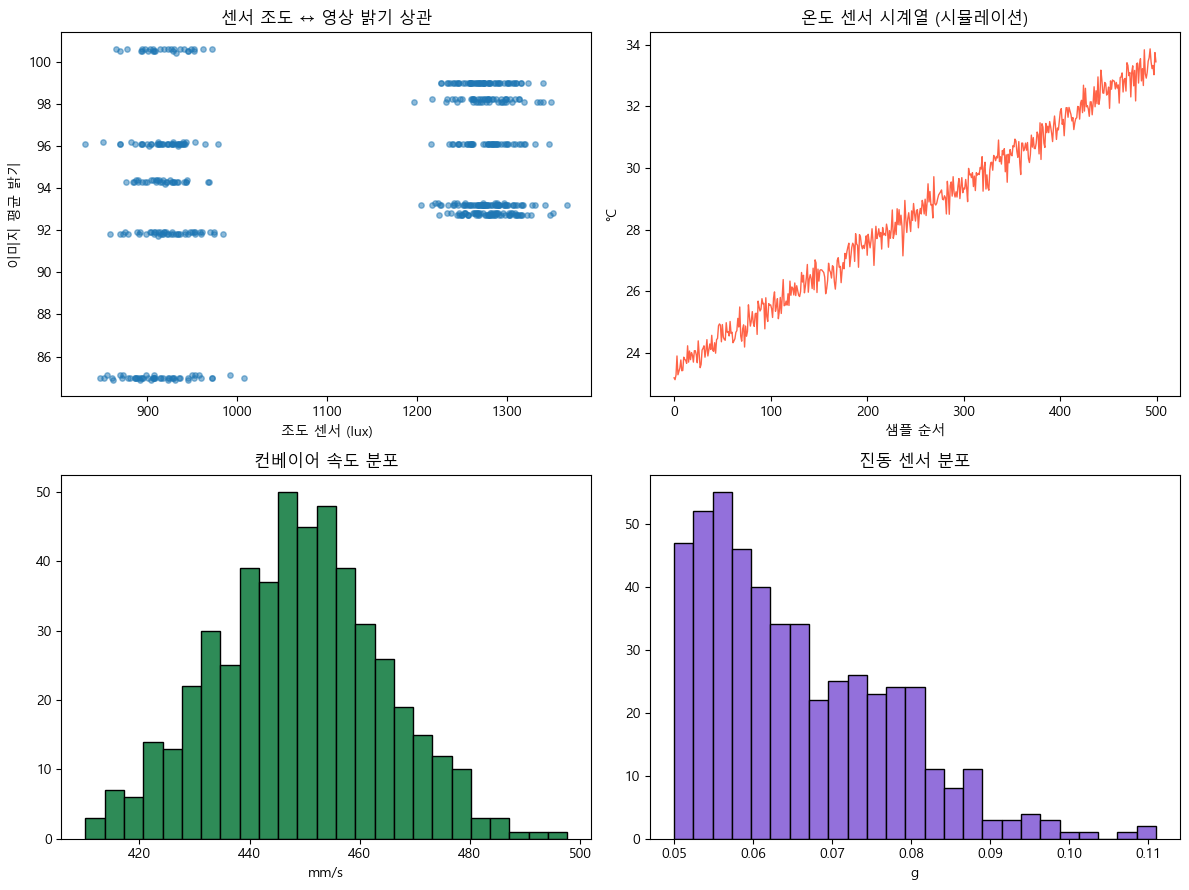

상관계수 행렬:


,lux_sensor,image_brightness,temp_c,vibration_g
lux_sensor,1.000,0.343,0.828,0.063
image_brightness,0.343,1.000,0.279,0.056
temp_c,0.828,0.279,1.000,0.062
vibration_g,0.063,0.056,0.062,1.000


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(multimodal_df["lux_sensor"], multimodal_df["image_brightness"], alpha=0.5, s=15)
axes[0, 0].set_xlabel("조도 센서 (lux)")
axes[0, 0].set_ylabel("이미지 평균 밝기")
axes[0, 0].set_title("센서 조도 ↔ 영상 밝기 상관")

axes[0, 1].plot(multimodal_df["temp_c"], color="tomato", linewidth=1)
axes[0, 1].set_title("온도 센서 시계열 (시뮬레이션)")
axes[0, 1].set_xlabel("샘플 순서")
axes[0, 1].set_ylabel("°C")

axes[1, 0].hist(multimodal_df["conveyor_mm_s"], bins=25, color="seagreen", edgecolor="black")
axes[1, 0].set_title("컨베이어 속도 분포")
axes[1, 0].set_xlabel("mm/s")

axes[1, 1].hist(multimodal_df["vibration_g"], bins=25, color="mediumpurple", edgecolor="black")
axes[1, 1].set_title("진동 센서 분포")
axes[1, 1].set_xlabel("g")

plt.tight_layout()
plt.show()

corr = multimodal_df[["lux_sensor", "image_brightness", "temp_c", "vibration_g"]].corr()
print("상관계수 행렬:")
display(corr.round(3))

## 3. 데이터 유형별 ML 문제 정의 매트릭스

동일한 AOI 라인에서도 **데이터 유형에 따라 과제가 달라집니다.**

| 데이터 | 가능한 ML 과제 | 입력→출력 | 활용 시점 |
|--------|--------------|----------|----------|
| **영상** | 객체 검출 | 이미지 → bbox+class | **결함 위치 특정 (채택)** |
| **영상** | 이상 탐지 | 이미지 → 정상/이상 점수 | 라벨 부족 시 |
| **조도 센서** | 회귀/분류 | lux → 촬영 품질 등급 | 조명 보정 |
| **온도** | 시계열 예측 | temp(t) → temp(t+k) | 예지 보전 |
| **진동** | 이상 탐지 | vibration → 설비 이상 | 설비 고장 예측 |
| **멀티모달** | 융합 분류 | 영상+센서 → NG 확률 | 고신뢰도 최종 판정 |

In [4]:
# 문제 정의 의사결정 트리 (실습용)
decision_questions = {
    "Q1_결함위치_필요": {
        "question": "결함의 정확한 위치(좌표)가 필요한가?",
        "yes": "객체 검출 또는 세그멘테이션",
        "no": "Q2_라벨_충분",
    },
    "Q2_라벨_충분": {
        "question": "클래스별 라벨이 충분히 있는가?",
        "yes": "이미지 분류 (multi-class)",
        "no": "이상 탐지 (Anomaly Detection)",
    },
    "Q3_센서_활용": {
        "question": "센서 데이터가 영상과 동기화되어 있는가?",
        "yes": "멀티모달 융합 모델 검토",
        "no": "영상 단독 모델 우선",
    },
}

def run_decision_tree(need_location=True, enough_labels=True, sensor_synced=False):
    steps = []
    if need_location:
        result = "객체 검출 (Object Detection) ← 본 프로젝트"
        steps.append(("Q1", "결함 위치 필요 → Yes", result))
    elif enough_labels:
        result = "이미지 분류 (Classification)"
        steps.append(("Q1", "결함 위치 필요 → No", "Q2로 이동"))
        steps.append(("Q2", "라벨 충분 → Yes", result))
    else:
        result = "이상 탐지 (Anomaly Detection)"
        steps.append(("Q1", "결함 위치 필요 → No", "Q2로 이동"))
        steps.append(("Q2", "라벨 충분 → No", result))

    if sensor_synced:
        steps.append(("Q3", "센서 동기화 → Yes", "멀티모달 융합 확장 가능"))
    else:
        steps.append(("Q3", "센서 동기화 → No", "영상 단독 모델 우선"))
    return steps

for step in run_decision_tree(need_location=True, sensor_synced=False):
    print(f"[{step[0]}] {step[1]}")
    if "←" in step[2] or "가능" in step[2] or "우선" in step[2]:
        print(f"      → {step[2]}")

[Q1] 결함 위치 필요 → Yes
      → 객체 검출 (Object Detection) ← 본 프로젝트
[Q3] 센서 동기화 → No
      → 영상 단독 모델 우선


## 4. 영상 어노테이션 품질 실습

라벨 품질은 모델 성능의 **상한(ceiling)** 을 결정합니다.
아래 코드로 **bbox 크기 이상치**와 **라벨 누락 가능성**을 점검합니다.

In [5]:
def load_yolo_labels(label_path: Path):
    boxes = []
    for line in label_path.read_text(encoding="utf-8").strip().splitlines():
        if line.strip():
            cls, cx, cy, w, h = map(float, line.split())
            boxes.append((int(cls), cx, cy, w, h))
    return boxes

# train 라벨 품질 스캔 (샘플 2000장)
label_files = sorted((DATA_ROOT / "train" / "labels").glob("*.txt"))[:2000]
issues = []

for lbl_path in label_files:
    boxes = load_yolo_labels(lbl_path)
    if not boxes:
        issues.append({"stem": lbl_path.stem, "issue": "empty_label", "detail": "라벨 파일 비어있음"})
        continue
    for cls, cx, cy, w, h in boxes:
        if cls not in CLASS_NAMES:
            issues.append({"stem": lbl_path.stem, "issue": "invalid_class", "detail": f"class={cls}"})
        if w * h < 0.0005:
            issues.append({"stem": lbl_path.stem, "issue": "tiny_bbox", "detail": f"area={w*h:.5f}"})
        if w * h > 0.25:
            issues.append({"stem": lbl_path.stem, "issue": "large_bbox", "detail": f"area={w*h:.4f}"})
        if not (0 <= cx <= 1 and 0 <= cy <= 1):
            issues.append({"stem": lbl_path.stem, "issue": "center_oob", "detail": f"cx={cx}, cy={cy}"})

issue_df = pd.DataFrame(issues)
print(f"검사 라벨 수: {len(label_files)}")
print(f"이슈 건수  : {len(issue_df)}")
if len(issue_df):
    display(issue_df.groupby("issue").size().to_frame("count"))
else:
    print("이슈 없음 — 라벨 품질 양호")

검사 라벨 수: 2000
이슈 건수  : 14


,count
issue,
tiny_bbox,14


## 5. 📝 종합 실습: 문제 정의 워크시트

팀별로 아래 표를 작성하고 발표하세요.

### A. 영상 데이터 문제 정의
| 항목 | 작성 |
|------|------|
| 입력 | AOI RGB 이미지, 해상도 ___, 채널 3 |
| 출력 | ___ (bbox / class / score) |
| 과제 유형 | ___ |
| 평가 지표 | ___ |

### B. 센서 데이터 문제 정의 (시뮬레이션 기반)
| 센서 | ML 과제 | 입력→출력 | 비즈니스 가치 |
|------|---------|----------|--------------|
| 조도 | | lux → | 촬영 품질 보장 |
| 온도 | | temp(t) → | 예지 보전 |
| 진동 | | vibration → | 설비 이상 조기 감지 |

### C. 멀티모달 확장 시나리오
> 영상 모델이 **불확실(confidence < 0.7)** 할 때, 센서 데이터를 추가 입력으로
> 2차 판정하는 **cascade 아키텍처**를 설계하세요.

```
[AOI 촬영] → [Vision AI 1차] → confidence ≥ 0.7? → OK/NG 출력
                                    ↓ No
                              [센서+영상 융합 2차] → 최종 판정
```

In [6]:
# 멀티모달 cascade 시뮬레이션 (개념 실습)
# Vision AI confidence가 낮을 때 센서 특징으로 2차 판정

multimodal_df["vision_confidence"] = rng.uniform(0.4, 0.99, size=len(multimodal_df))
multimodal_df["sensor_anomaly_score"] = (
    (multimodal_df["lux_sensor"] - multimodal_df["lux_sensor"].mean()).abs() / multimodal_df["lux_sensor"].std()
    + (multimodal_df["vibration_g"] - multimodal_df["vibration_g"].mean()).abs() / multimodal_df["vibration_g"].std()
)

THRESHOLD = 0.7
low_conf = multimodal_df[multimodal_df["vision_confidence"] < THRESHOLD]
print(f"1차 Vision AI 저신뢰 샘플: {len(low_conf)} / {len(multimodal_df)} ({100*len(low_conf)/len(multimodal_df):.1f}%)")
print(f"저신뢰 샘플의 평균 센서 이상 점수: {low_conf['sensor_anomaly_score'].mean():.3f}")
print(f"고신뢰 샘플의 평균 센서 이상 점수: {multimodal_df[multimodal_df['vision_confidence'] >= THRESHOLD]['sensor_anomaly_score'].mean():.3f}")
print("\n→ 저신뢰 구간에서 센서 데이터를 활용하면 2차 판정 정확도 향상 가능")

1차 Vision AI 저신뢰 샘플: 265 / 500 (53.0%)
저신뢰 샘플의 평균 센서 이상 점수: 1.804
고신뢰 샘플의 평균 센서 이상 점수: 1.782

→ 저신뢰 구간에서 센서 데이터를 활용하면 2차 판정 정확도 향상 가능


---

## 프로젝트 요약

| 단계 | 노트북 | 핵심 산출물 |
|------|--------|------------|
| 1 | `01_산업시나리오_문제정의` | ML 문제 정의서, ROI, KPI |
| 2 | `02_데이터셋_구축_EDA` | 데이터 품질 리포트, 클래스 분포 |
| 3 | `03_센서영상_문제정의_실습` | 멀티모달 시나리오, 의사결정 트리 |

**다음 학습**: YOLOv8 등 객체 검출 모델 학습 → Edge 배포 → MLOps 파이프라인